In [2]:
from google.colab import drive
drive.mount('/content/drive')

import os
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from PIL import Image

Mounted at /content/drive


In [13]:
BASE = Path('/content/drive/MyDrive/3dcv-project')

DATA_DIR = BASE / 'data'
RESULTS_DIR = BASE / 'results' / 'track_b'
CODE_DIR = BASE / 'code'

VKITTI_ROOT = DATA_DIR / 'vkitti2'
KITTI_ROOT = DATA_DIR / 'kitti'

METRICS_CSV = RESULTS_DIR / 'B3_depth_metrics_vkitti.csv'

# Папка с предсказанными depth .npy
DEPTH_PRED_DIR = RESULTS_DIR / 'depth_pred_vkitti'

OUTPUT_ABSREL_PLOT = RESULTS_DIR / 'B5_absrel_by_scene.png'
OUTPUT_FAILURE_CASES = RESULTS_DIR / 'B5_failure_cases.png'

RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print('BASE:', BASE)
print('VKITTI_ROOT exists:', VKITTI_ROOT.exists())
print('KITTI_ROOT exists:', KITTI_ROOT.exists())
print('METRICS_CSV exists:', METRICS_CSV.exists())
print('DEPTH_PRED_DIR exists:', DEPTH_PRED_DIR.exists())

BASE: /content/drive/MyDrive/3dcv-project
VKITTI_ROOT exists: True
KITTI_ROOT exists: True
METRICS_CSV exists: True
DEPTH_PRED_DIR exists: True


In [4]:
SHARED_DIR = BASE / 'code' / 'shared'
VKITTI_LOADER_DIR = BASE / 'code' / 'shared' / 'vkitti'

sys.path.append(str(SHARED_DIR))
sys.path.append(str(VKITTI_LOADER_DIR))

import _loader as vkitti_loader

loader = vkitti_loader.VKITTI2Loader(str(VKITTI_ROOT))

print('VKITTI scenes:', loader.SCENES)
print('VKITTI variations:', loader.VARIATIONS)

VKITTI scenes: ['Scene01', 'Scene02', 'Scene06', 'Scene18', 'Scene20']
VKITTI variations: ['clone', 'fog', 'morning', 'overcast', 'rain', 'sunset']


# Группировка по сценам

In [6]:
df_vkitti = pd.read_csv(METRICS_CSV)
agg = df_vkitti.groupby('scene')[['AbsRel', 'RMSE', 'δ < 1.25']].mean()

print(agg)

           AbsRel       RMSE  δ < 1.25
scene                                 
Scene01  0.491387   9.232645  0.390523
Scene02  0.608465  11.566171  0.353028
Scene06  0.494558  10.278358  0.431545
Scene18  0.542014   9.991820  0.397100
Scene20  0.447655   8.713697  0.381146


# Boxplot AbsRel по сценам

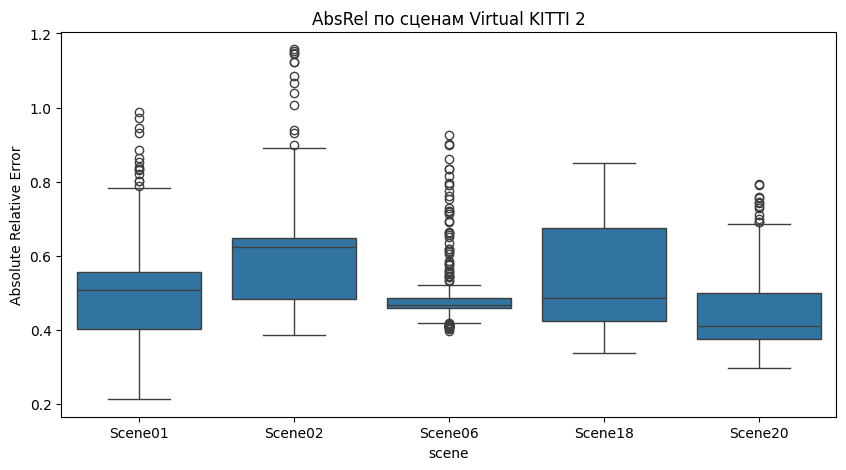

In [9]:
import seaborn as sns

plt.figure(figsize=(10, 5))

sns.boxplot(data=df_vkitti, x='scene', y='AbsRel')

plt.title('AbsRel по сценам Virtual KITTI 2')

plt.ylabel('Absolute Relative Error')

plt.savefig('/content/drive/MyDrive/3dcv-project/results/track_b/B5_absrel_by_scene.png',

            dpi=150, bbox_inches='tight')

plt.show()

In [14]:
from pathlib import Path

scene_pred_dir = Path(DEPTH_PRED_DIR) / 'Scene02'

print(scene_pred_dir)
print('exists:', scene_pred_dir.exists())

if scene_pred_dir.exists():
    files = sorted(scene_pred_dir.glob('*.npy'))
    print('npy count:', len(files))
    print(files[:10])

/content/drive/MyDrive/3dcv-project/results/track_b/depth_pred_vkitti/Scene02
exists: True
npy count: 233
[PosixPath('/content/drive/MyDrive/3dcv-project/results/track_b/depth_pred_vkitti/Scene02/00000.npy'), PosixPath('/content/drive/MyDrive/3dcv-project/results/track_b/depth_pred_vkitti/Scene02/00001.npy'), PosixPath('/content/drive/MyDrive/3dcv-project/results/track_b/depth_pred_vkitti/Scene02/00002.npy'), PosixPath('/content/drive/MyDrive/3dcv-project/results/track_b/depth_pred_vkitti/Scene02/00003.npy'), PosixPath('/content/drive/MyDrive/3dcv-project/results/track_b/depth_pred_vkitti/Scene02/00004.npy'), PosixPath('/content/drive/MyDrive/3dcv-project/results/track_b/depth_pred_vkitti/Scene02/00005.npy'), PosixPath('/content/drive/MyDrive/3dcv-project/results/track_b/depth_pred_vkitti/Scene02/00006.npy'), PosixPath('/content/drive/MyDrive/3dcv-project/results/track_b/depth_pred_vkitti/Scene02/00007.npy'), PosixPath('/content/drive/MyDrive/3dcv-project/results/track_b/depth_pred_vki

In [16]:
def align_depth_lstsq(pred, gt, mask):
    """
    Align relative predicted depth to metric GT depth:

        gt ≈ scale * pred + shift
    """

    pred_valid = pred[mask].reshape(-1)
    gt_valid = gt[mask].reshape(-1)

    A = np.stack(
        [pred_valid, np.ones_like(pred_valid)],
        axis=1
    )

    scale, shift = np.linalg.lstsq(
        A,
        gt_valid,
        rcond=None
    )[0]

    pred_metric = scale * pred + shift

    return pred_metric, scale, shift

print('✅ align_depth_lstsq ready')

✅ align_depth_lstsq ready


In [18]:
def align_depth_lstsq(pred, gt, mask):

    """

    Подбирает scale и shift через least squares: gt ≈ scale * pred + shift

    Возвращает aligned predicted depth в метрах.

    """

    pred_valid = pred[mask]

    gt_valid = gt[mask]



    A = np.stack([pred_valid, np.ones_like(pred_valid)], axis=1)

    scale, shift = np.linalg.lstsq(A, gt_valid, rcond=None)[0]



    return scale * pred + shift, scale, shift

5 худших кадров:
       scene  frame    AbsRel
556  Scene02    110  1.157404
555  Scene02    109  1.153824
558  Scene02    112  1.148521
559  Scene02    113  1.145564
554  Scene02    108  1.123535


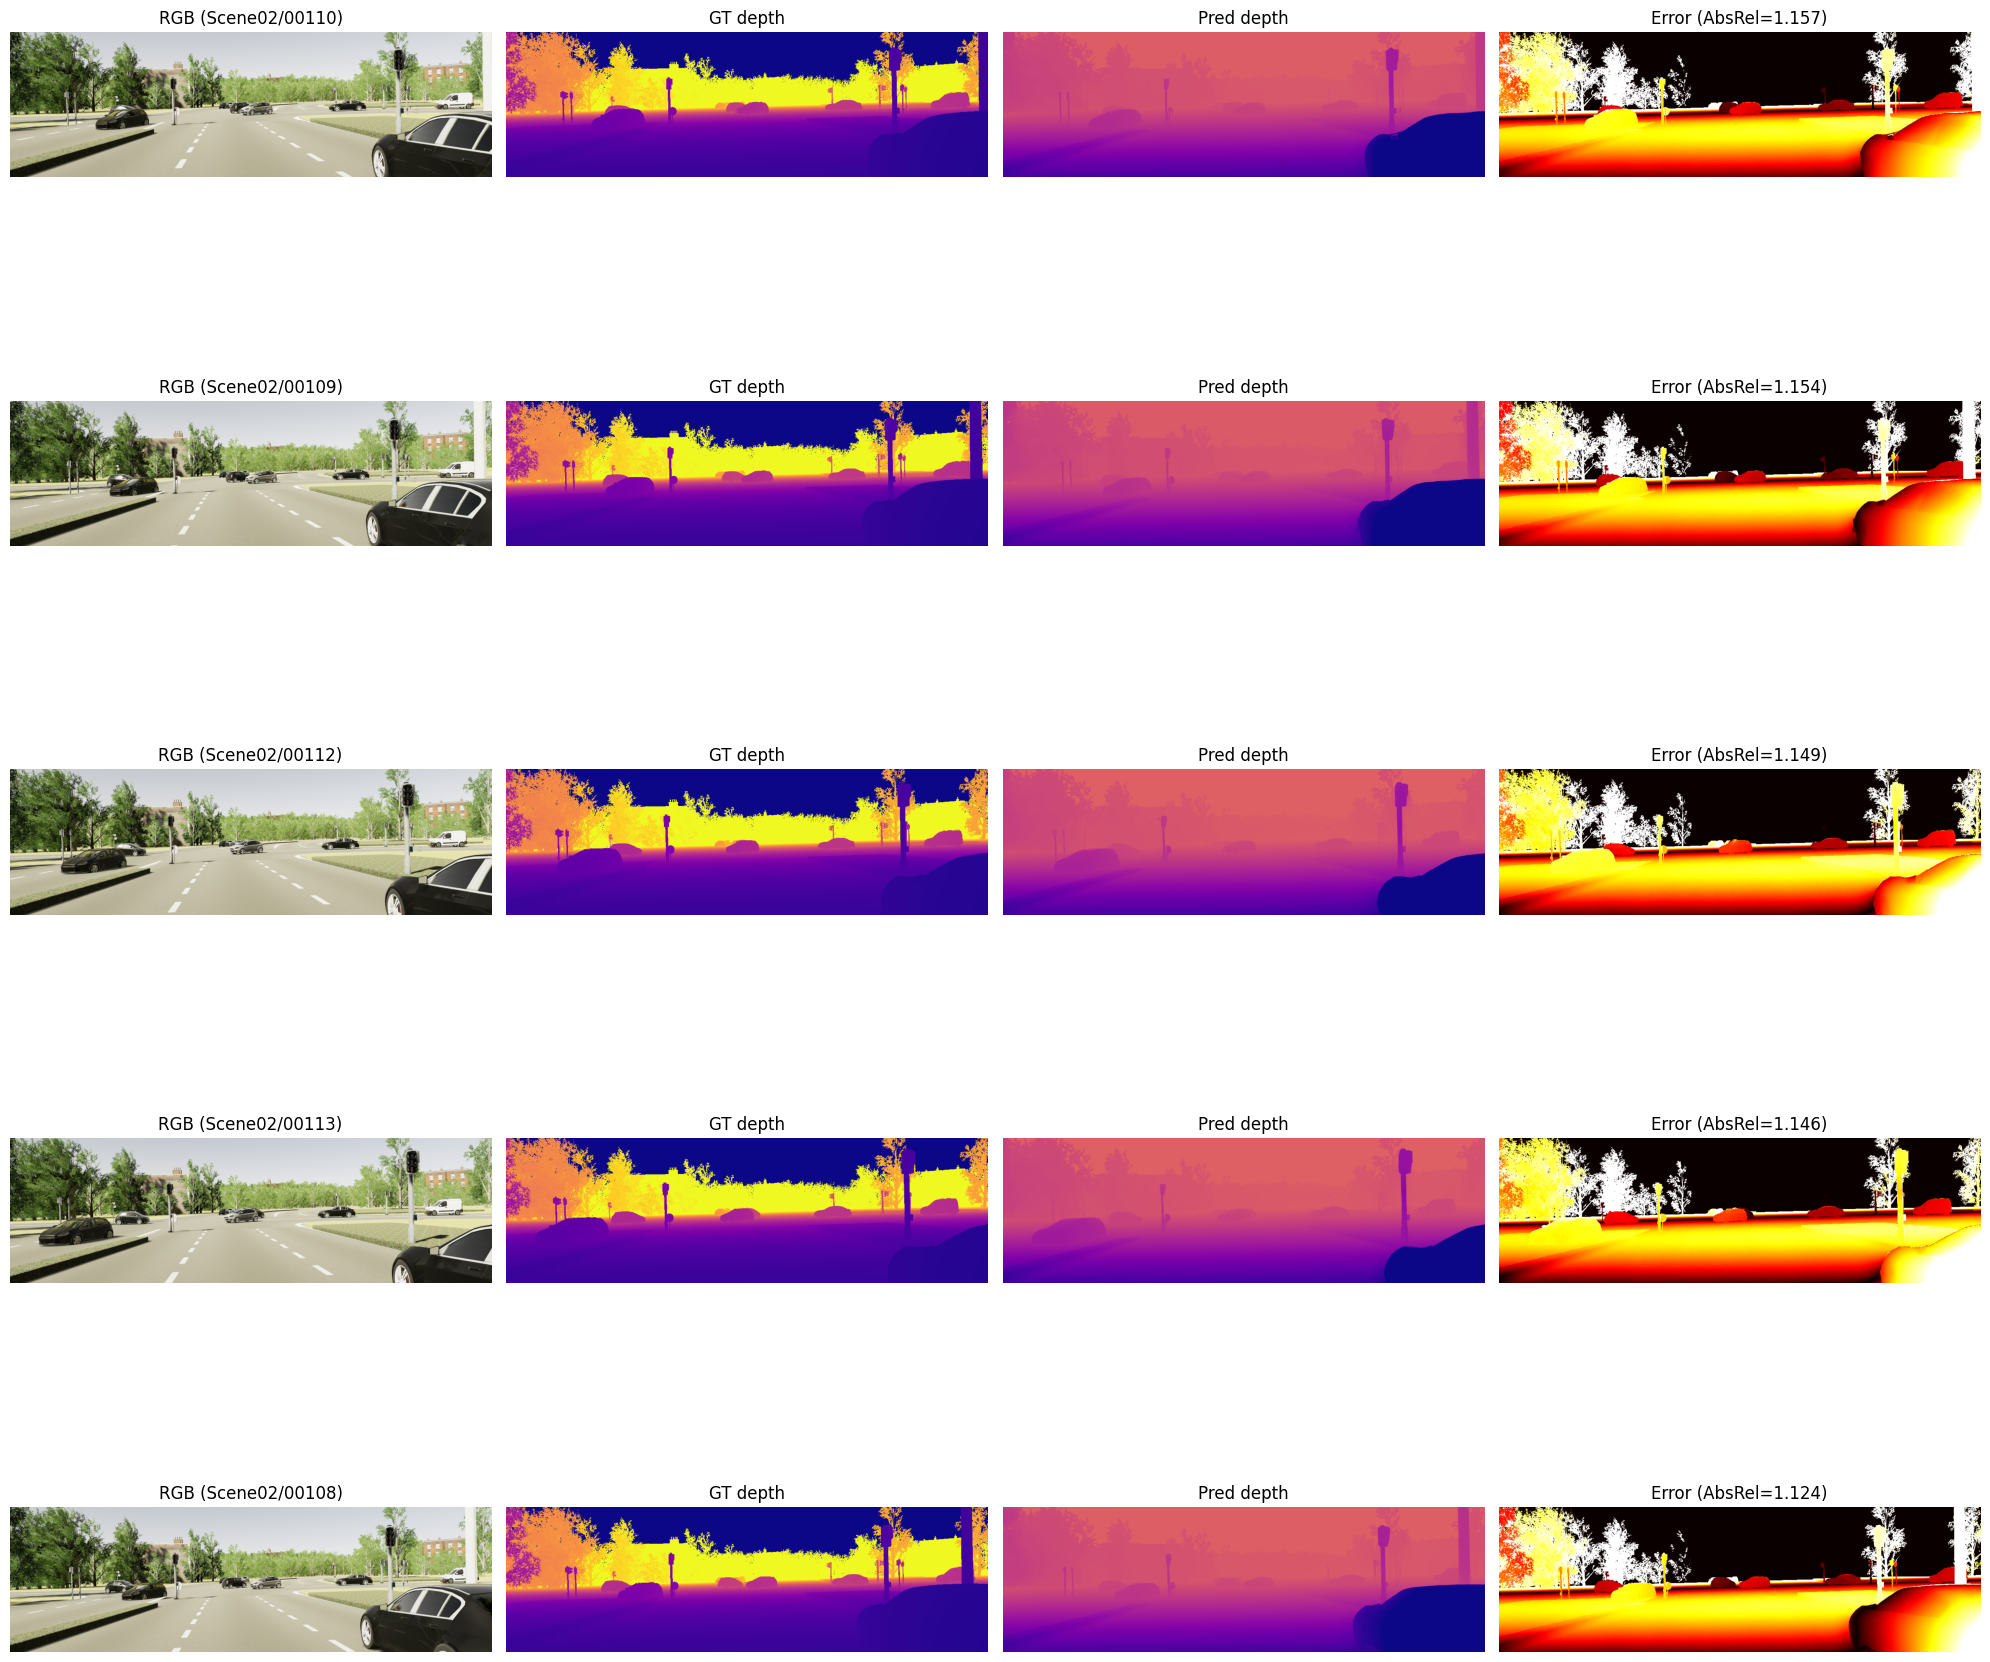

Saved: /content/drive/MyDrive/3dcv-project/results/track_b/B5_failure_cases.png


In [19]:
worst_frames = df_vkitti.nlargest(5, 'AbsRel')[['scene', 'frame', 'AbsRel']]

print('5 худших кадров:')
print(worst_frames)

fig, axes = plt.subplots(5, 4, figsize=(20, 20))

for i, row in enumerate(worst_frames.itertuples()):

    scene = row.scene
    frame_id = f'{int(row.frame):05d}'   # 110 -> 00110

    # Загружаем RGB и GT depth через VKITTI loader
    rgb = loader.load_rgb(scene, 'clone', frame_id)
    gt = loader.load_depth(scene, 'clone', frame_id)

    # Загружаем predicted depth
    pred_path = Path(DEPTH_PRED_DIR) / scene / f'{frame_id}.npy'

    if not pred_path.exists():
        raise FileNotFoundError(f'Predicted depth not found: {pred_path}')

    pred_rel = np.load(pred_path)

    # Resize prediction если размер не совпадает с GT
    if pred_rel.shape != gt.shape:
        pred_rel = np.array(
            Image.fromarray(pred_rel.astype(np.float32)).resize(
                (gt.shape[1], gt.shape[0])
            )
        )

    # Valid depth mask
    mask = (gt > 0.1) & (gt < 80)

    # Align relative prediction to metric GT
    pred_metric, _, _ = align_depth_lstsq(pred_rel, gt, mask)

    # Error map
    error = np.abs(pred_metric - gt)
    error[~mask] = 0

    # Plot
    axes[i, 0].imshow(rgb)
    axes[i, 0].set_title(f'RGB ({scene}/{frame_id})')

    axes[i, 1].imshow(gt, cmap='plasma', vmin=0, vmax=80)
    axes[i, 1].set_title('GT depth')

    axes[i, 2].imshow(pred_metric, cmap='plasma', vmin=0, vmax=80)
    axes[i, 2].set_title('Pred depth')

    axes[i, 3].imshow(error, cmap='hot', vmin=0, vmax=20)
    axes[i, 3].set_title(f'Error (AbsRel={row.AbsRel:.3f})')

    for j in range(4):
        axes[i, j].axis('off')

plt.tight_layout()

output_path = Path('/content/drive/MyDrive/3dcv-project/results/track_b/B5_failure_cases.png')

plt.savefig(
    output_path,
    dpi=150,
    bbox_inches='tight'
)

plt.show()

print('Saved:', output_path)

На этой картинке каждая строка — один из 5 худших кадров по AbsRel.

Слева направо: RGB-изображение, истинная глубина GT depth, предсказанная глубина Pred depth, карта ошибки Error.


Хорошее предсказание глубины должно быть похоже на GT depth: близкие объекты должны оставаться близкими, дальние — дальними, а границы машин, деревьев, дороги и тротуара должны быть достаточно чёткими.


Плохое предсказание видно там, где Pred depth сильно сглаживает сцену: вместо резких переходов глубины модель выдаёт плавный градиент.

Вывод: Плохо предсказывает. На примерах это особенно заметно для деревьев, машин, столбов и линии горизонта — в GT depth они имеют выраженные перепады, а в Pred depth они выглядят более размыто.

Карта ошибки показывает модуль разницы:
|pred_metric - gt|

Светлые/жёлто-белые области — большая ошибка, тёмные области — малая ошибка. Поэтому хорошая карта ошибки должна быть в основном тёмной. Плохая — когда большие светлые области занимают значительную часть изображения.

Вывод: самые светлый объект это деревья, которые расположены в дали. Это означает, что модель плохо восстановила глубину в дальних и структурно сложных областях.

Технически здесь видно несколько типичных проблем. Во-первых, Pred depth имеет более гладкую структуру, чем GT depth: модель восстанавливает общий тренд глубины “ближе внизу, дальше к горизонту”, но приэтом сильно сглаживает и теряет локальные детали.

Во-вторых, ошибки концентрируются на местах резкого изменения глубины, например края автомобилей, деревья, столбы, бордюры.

В-третьих, синтетический GT у VKITTI2 очень резкий и точный по объектам, а monocular depth model обычно выдаёт более сглаженную карту, поэтому ошибка на границах объектов ожидаемо высокая.

В этих пяти кадрах все хужшие карты относятся к Scene02 и соседним frame ID 00108–00113. Это важно: ошибка не случайно распределена по датасету, а возникает на последовательном участке одной сцены.

Значит, проблема может быть связана с конкретной геометрией или визуальными условиями этого фрагмента: широкая дорога, много дальних объектов, деревья и тонкие структуры, сильные depth discontinuities. Это хороший аргумент для domain gap analysis: модель переносит общий depth pattern, но на синтетических сценах VKITTI2 даёт систематические ошибки в деталях и на дальних областях.


